In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import GMM

In [2]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.graph_objects as go

In [3]:
# Import Data
SPdata = pd.read_pickle('PreparedData/sp500_scaled_features.pkl')

In [4]:
# Split Dataset
X_train = tf.cast(SPdata[:'2021-12-31'], dtype = tf.float32)
X_CV = tf.cast(SPdata['2022-01-01':'2023-12-31'], dtype = tf.float32)
X_test = tf.cast(SPdata['2024-01-01':], dtype = tf.float32)

## Start Training --- Find the best K

In [5]:
K_list = [2,3,4,5,6,7]
gmm_model_para = {}
Result = []
for idx, K in enumerate(K_list):
    print(f'--- Training Classifier: Number of Centroids K = {K}. Round: ({idx+1}/{len(K_list)})---')
    print("K-Means Initialization...")
    kmeans = GMM.TF_kmeans(K)
    mu_init, pi_init, sigma_init = kmeans.gmm_init_params(X_train)

    print("Running GMM Training...")
    gmm = GMM.TF_GMM(K, max_iters=150, tol=1e-4)
    gamma, log_likelihood, aic, bic = gmm.fit(X_train, mu_init, pi_init, sigma_init, verbose=True)

    gmm_model_para[K] = {
        'Pi': gmm.pi.numpy(), 'Mu': gmm.mu.numpy(), 'Sigma': gmm.sigma.numpy()
    }
    Result.append([K, log_likelihood, aic, bic])
    print(f'--- End of Round {idx + 1} ---'+'\n')

--- Training Classifier: Number of Centroids K = 2. Round: (1/6)---
K-Means Initialization...
Running GMM Training...
---GMM training---
Iteration:   0 | Log_likelihood: -25574.5488 | Shift: inf
Iteration:   5 | Log_likelihood: -22016.5000 | Shift: 6.132812
Iteration:  10 | Log_likelihood: -22011.7988 | Shift: 0.197266
Iteration:  15 | Log_likelihood: -22011.5371 | Shift: 0.013672
Iteration:  20 | Log_likelihood: -22011.5195 | Shift: 0.000000
---Iteration end at 20.---

--- Model Metrics ---
Total Params : 41
Final Log-L  : -22011.5195
AIC          : 44105.0391
BIC          : 44365.7930
--- End of Round 1 ---

--- Training Classifier: Number of Centroids K = 3. Round: (2/6)---
K-Means Initialization...
Running GMM Training...
---GMM training---
Iteration:   0 | Log_likelihood: -23784.3320 | Shift: inf
Iteration:   5 | Log_likelihood: -21559.7188 | Shift: 107.980469
Iteration:  10 | Log_likelihood: -21395.9766 | Shift: 13.062500
Iteration:  15 | Log_likelihood: -21373.9707 | Shift: 1.61

In [6]:
Result_df = pd.DataFrame(Result, columns=['K','Log_likelihood', 'AIC', 'BIC']).set_index('K')
Result_df

,Log_likelihood,AIC,BIC
K,,,
2,-22011.519531,44105.039062,44365.792969
3,-21370.681641,42865.363281,43259.671875
4,-21013.306641,42192.613281,42720.480469
5,-20908.468750,42024.937500,42686.359375
6,-20819.933594,41889.867188,42684.847656
7,-20775.988281,41843.976562,42772.511719


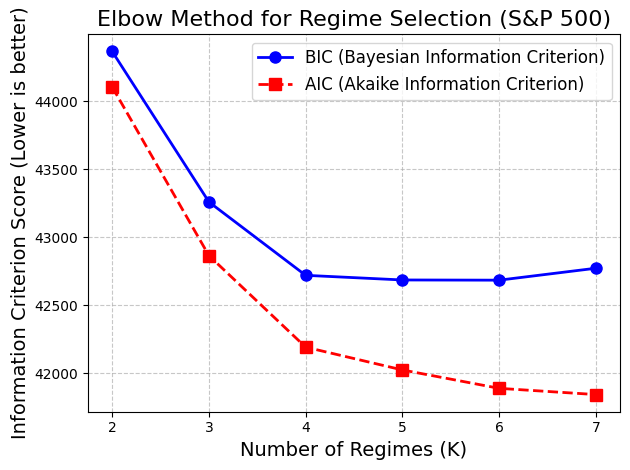

In [7]:
#Elbow Plot
plt.plot(Result_df.index, Result_df['BIC'], 'b-o', linewidth=2, markersize=8, label='BIC (Bayesian Information Criterion)')

plt.plot(Result_df.index, Result_df['AIC'], 'r--s', linewidth=2, markersize=8, label='AIC (Akaike Information Criterion)')

plt.title('Elbow Method for Regime Selection (S&P 500)', fontsize=16)
plt.xlabel('Number of Regimes (K)', fontsize=14)
plt.ylabel('Information Criterion Score (Lower is better)', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(Result_df.index)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

## CV-set OOS_likelihood

In [30]:
TLL = []
for K in K_list:
    Mu, Sigma, Pi = gmm_model_para[K]['Mu'], gmm_model_para[K]['Sigma'], gmm_model_para[K]['Pi']
    gamma, log_likelihood_cv = GMM.GMM_predict(X_CV, Mu, Sigma, Pi)
    TLL.append([K, round(log_likelihood_cv.numpy(),4)])

In [31]:
TLL_df = pd.DataFrame(TLL, columns=['K', 'Log_Likelihood']).set_index('K')
TLL_df

,Log_Likelihood
K,
2,-3493.859619
3,-3467.798096
4,-3390.664307
5,-3370.477539
6,-3389.897705
7,-3390.101562


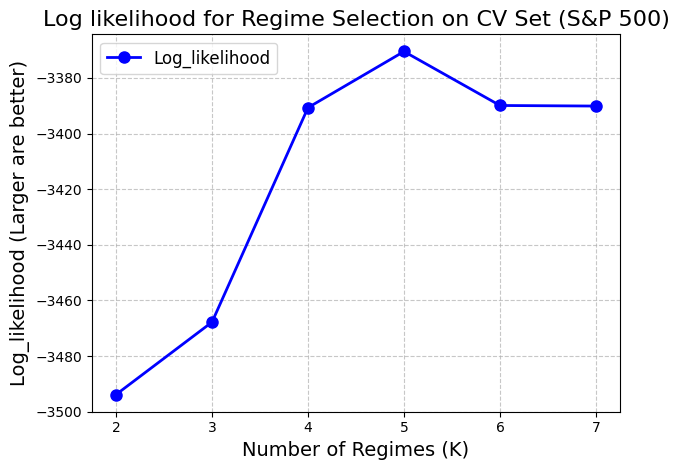

In [32]:
#Likelihood on CV set
plt.plot(TLL_df.index, TLL_df['Log_Likelihood'], 'b-o', linewidth=2, markersize=8, label='Log_likelihood')

plt.title('Log likelihood for Regime Selection on CV Set (S&P 500)', fontsize=16)
plt.xlabel('Number of Regimes (K)', fontsize=14)
plt.ylabel('Log_likelihood (Larger are better)', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(TLL_df.index)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

### Best K

In [33]:
Best_K = 4
Mu, Sigma, Pi = gmm_model_para[Best_K]['Mu'], gmm_model_para[Best_K]['Sigma'], gmm_model_para[Best_K]['Pi']
gamma, TLL = GMM.GMM_predict(X_train, Mu, Sigma, Pi)

In [34]:
SP_original = pd.read_csv('RawData/sp500_market_features_2005_2025.csv', index_col= 0, parse_dates=True)
SP_original['RR'] = np.log(SP_original['Close'] / SP_original['Close'].shift(1))
SP_original = SP_original['2005-01-04':'2021-12-31']
SP_original

,Close,TBR,VIX,Volume,OAS,RR
Date,,,,,,
2005-01-04,1188.050049,4.283,13.980000,1721000000,2.97,-0.011740
2005-01-05,1183.739990,4.277,14.090000,1738900000,3.04,-0.003634
2005-01-06,1187.890015,4.272,13.580000,1569100000,3.09,0.003500
2005-01-07,1186.189941,4.285,13.490000,1477900000,3.07,-0.001432
2005-01-10,1190.250000,4.278,13.230000,1490400000,3.10,0.003417
...,...,...,...,...,...,...
2021-12-27,4791.189941,1.481,17.680000,2770290000,3.02,0.013744
2021-12-28,4786.350098,1.481,17.540001,2707920000,3.01,-0.001011
2021-12-29,4793.060059,1.543,16.950001,2963310000,3.03,0.001401


In [35]:
# 'Hard Label'
hard_labels = tf.argmax(gamma, axis=1).numpy()
SP_original.reset_index(inplace=True)
SP_original['Regime'] = hard_labels
SP_original.head()

,Date,Close,TBR,VIX,Volume,OAS,RR,Regime
0,2005-01-04,1188.050049,4.283,13.98,1721000000,2.97,-0.011740,2
1,2005-01-05,1183.739990,4.277,14.09,1738900000,3.04,-0.003634,1
2,2005-01-06,1187.890015,4.272,13.58,1569100000,3.09,0.003500,1
3,2005-01-07,1186.189941,4.285,13.49,1477900000,3.07,-0.001432,1
4,2005-01-10,1190.250000,4.278,13.23,1490400000,3.10,0.003417,1


In [36]:
feature_cols = ['RR', 'TBR', 'VIX', 'Volume', 'OAS', 'Close']
print("\n--- Regime Profiling (Factor Means) ---")
regime_profile = SP_original.groupby('Regime')[feature_cols].mean()
regime_profile['Count_Days'] = SP_original.groupby('Regime').size()

regime_profile


--- Regime Profiling (Factor Means) ---


,RR,TBR,VIX,Volume,OAS,Close,Count_Days
Regime,,,,,,,
0,0.000582,2.801186,16.555494,3.451294e+09,4.898379,1918.253754,253
1,0.001103,2.824611,15.511301,3.360040e+09,4.468375,2032.488269,2314
2,-0.000462,2.689631,21.674150,4.210384e+09,5.960696,1893.590022,1465
3,-0.002687,2.443171,41.082208,6.051605e+09,10.674583,1691.130788,240


In [37]:
color_map = {0: 'blue', 1: 'green', 2: 'red', 3: 'orange'} 
regime_names = {
    0: 'Regime 0', 
    1: 'Regime 1', 
    2: 'Regime 2',
    3: 'Regime 3'
}

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=SP_original['Date'],
    y=SP_original['Close'],
    mode='lines',
    name='S&P 500 Trend',
    line=dict(color='black', width=1),
    opacity=0.3, 
    hoverinfo='skip' 
))


for regime in sorted(SP_original['Regime'].unique()):
    mask = SP_original['Regime'] == regime
    
    fig.add_trace(go.Scatter(
        x=SP_original[mask]['Date'],
        y=SP_original[mask]['Close'],
        mode='markers',
        name=regime_names.get(regime, f'Regime {regime}'),
        marker=dict(
            color=color_map.get(regime, 'blue'), 
            size=5, 
            line=dict(width=0.5, color='white') 
        ),
        hovertemplate='<b>Date:</b> %{x}<br>' +
                      '<b>ClosePrice:</b> %{y:.2f}<br>' +
                      '<b>Regime:</b> ' + regime_names.get(regime, f'Regime {regime}') +
                      '<extra></extra>'
    ))

fig.update_layout(
    title=dict(
        text='<b>S&P 500 Market Regimes Identified by GMM</b>',
        font=dict(size=20)
    ),
    xaxis_title='Date',
    yaxis_title='Close Price',
    template='plotly_white', 
    hovermode='closest',     
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01,
        bgcolor="rgba(255, 255, 255, 0.8)" 
    )
)
fig.update_xaxes(rangeslider_visible=True)
fig.show()